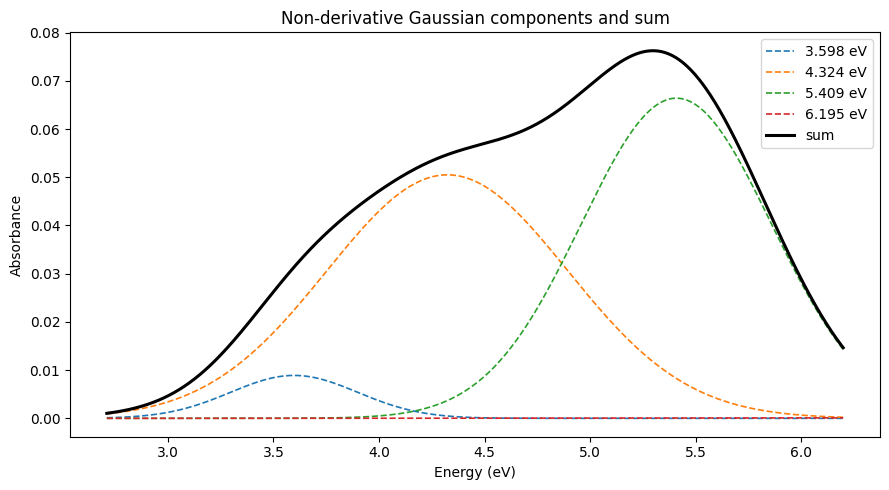

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


csv_path = Path("DATA/JRW Test saturated/Absorbance_1/nonDerivGaussians.csv")
gaussians = np.genfromtxt(csv_path, delimiter=",", names=True)


def gaussian(x, location, width, height):
    return height * np.exp(-((location - x) ** 2) / ((2 * width) ** 2)) ##see gaussian formula


x_min = np.min(gaussians["location"] - 4 * gaussians["width"])
x_max = 6.19920965
x = np.linspace(x_min, x_max, 1000)

components = []
for row in gaussians:
    components.append(gaussian(x, row["location"], row["width"], row["amplitude"]))

total = np.sum(components, axis=0)

plt.figure(figsize=(9, 5))
for row, y in zip(gaussians, components):
    plt.plot(x, y, "--", linewidth=1.2, label=f"{row['location']:.3f} eV")

plt.plot(x, total, color="black", linewidth=2.2, label="sum")
plt.xlabel("Energy (eV)")
plt.ylabel("Absorbance")
plt.title("Non-derivative Gaussian components and sum")
plt.legend()
plt.tight_layout()
plt.show()
